
**ADULT DATASET CLASSIFICATION - LOGISTIC REGRESSION & RANDOM FOREST**

**Task 1**: Classification project with EDA, preprocessing, modeling, and evaluation

**Dataset**: UCI Adult (Census Income) 



**Adult Dataset Classification (Logistic Regression & Random Forest)**

This notebook implements a full machine learning classification workflow using the
UCI Adult Census dataset. 
The goal of the project is to build, evaluate and interpret predictive models for two classification tasks based
on demographic and employment-related attributes.

**What this Code Does**

1. Loads the Adult dataset from OpenML and prepares it for analysis.

2. Performs Exploratory Data Analysis (EDA), including summary tables and visualisations of key 
variables such as workclass and hours-per-week.

3. Applies data preprocessing using scikit-learn pipelines:
Handling missing values, scaling numerical features, one-hot encoding categorical variables and 
dropping redundant or non-informative columns.

4. Builds two supervised machine learning models:
   a. Logistic Regression (interpretable baseline model)
   b. Random Forest Classifier (non-linear ensemble model)

5. Evaluates both models using:
accuracy, macro precision, macro recall, macro F1-score, confusion matrices and feature importance analysis (Random Forest).

6. Saves all outputs including plots, confusion matrices, and CSV summaries to a reusable results folder.

In [1]:

# Importing required libraries


# For creating result directories and handling file paths
import os

# Numerical operations
import numpy as np

# Tabular data handling
import pandas as pd

# Visualisation libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
zip_file_path = r"C:\Users\EDI\Downloads\adult.zip"
extract_folder = r"C:\Users\EDI\Downloads\adult_extracted"

import zipfile
import os

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("✅ Extraction complete!")


✅ Extraction complete!


**Importing essential Scikit-learn modules for the ML workflow**

These modules will enable a full end-to-end process that includes data loading, preprocessing, model building and evaluation

In [3]:
# Dataset access & data handling 
from sklearn.datasets import fetch_openml  
# fetch_openml allows a direct access to real-world benchmark datasets which in our case is the   Adult Income dataset
# from the OpenML repository, loading them into a pandas-compatible format for analysis.

from sklearn.model_selection import train_test_split  
# Splits the dataset into independent training and testing subsets.
# This ensures the model is trained on one portion of the data and evaluated on unseen data to measure generalization performance.

# Data preprocessing tools 
from sklearn.preprocessing import StandardScaler, OneHotEncoder  
# The StandardScaler adjusts numerical features so they have a mean of 0 and a 
# standard deviation of 1. 
# This helps ensure that features with larger values don’t overpower others during model training.

# The OneHotEncoder changes categorical features (like gender or education) into binary columns (0s and 1s),
# allowing machine learning models to understand and use them effectively.

from sklearn.compose import ColumnTransformer  
# It allows you to apply different preprocessing steps 
# like scaling for numerical features and encoding for categorical ones 
# all within one combined and organized workflow.

from sklearn.pipeline import Pipeline  
# The Pipeline class combines all preprocessing and modeling steps into a single, 
# well-structured workflow. It ensures that the same transformations used during 
# training are consistently applied when making predictions.

from sklearn.impute import SimpleImputer  
# It deals with missing values by filling them in using a selected strategy 
# such as the mean, median, or most frequent value 
# so that the model always gets complete and usable data.

# Machine learning models 
from sklearn.linear_model import LogisticRegression  
# Logistic Regression is a linear model used for classification. 
# It predicts the probability that a data point belongs to a certain class and 
# is often used as a reliable starting point for both binary and multiclass 
# classification tasks.

from sklearn.ensemble import RandomForestClassifier  
# Random Forest is an ensemble learning method that builds multiple decision trees
# and combines their predictions to improve accuracy and reduce overfitting.
# It captures complex, non-linear relationships between features and targets.

# Model evaluation metrics 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)



In summary, these metrics help evaluate how well the model performs:
1. **accuracy_score**: measures the overall correctness of the predictions.
2. **precision_score**: shows how many of the predicted positive cases were actually correct.
3. **recall_score**: measures how many of the actual positive cases were correctly identified.
4. **f1_score**: combines precision and recall into a single score for balance.
5. **classification_report**: provides a detailed summary of all these metrics for each class.
6. **confusion_matrix**: displays the true vs predicted values to visualize where the model gets things right or wrong.

In [4]:
# Experiment setup 
RANDOM_STATE = 52  
# Ensures reproducibility so results remain consistent all through multiple runs.

OUT_DIR = "adult_two_prediction_results"  
# Directory to store all outputs (plots, metrics, and tables) for organized results.

os.makedirs(OUT_DIR, exist_ok=True)  
# Creates the output folder if it does not already exist, preventing errors on multiple runs.

sns.set(style="whitegrid")  
# Gives all Seaborn plots a neat and clear look, making them easier to read and nicer to present.



In [5]:

# Load dataset from OpenML 
print("Fetching 'adult' dataset from OpenML...")

adult = fetch_openml(name='adult', version=2, as_frame=True) 
# Downloads the UCI Adult Census dataset from OpenML and loads it into a pandas DataFrame,
# combining all the features and the target variable in one place.

df_full = adult.frame.copy()  
# Makes a full copy of the dataset to keep the original safe, 
# allowing you to create new custom target columns later (like workclass or hours bucket).


print("Dataset shape:", df_full.shape)
print("Available columns:", df_full.columns.tolist())
# Shows the dataset’s size and column names to confirm it loaded correctly and includes all needed fields.

df_full.sample(8, random_state=52).to_csv(
    os.path.join(OUT_DIR, "adult_dataset_preview.csv"), index=False
)
# Saves a random sample of eight rows as a quick preview for documentation, 
# giving a more balanced snapshot than just showing the first few rows.

print("✅ Adult dataset successfully loaded and preview saved.")
# Confirms that the dataset has been successfully loaded, checked, and saved.

Fetching 'adult' dataset from OpenML...
Dataset shape: (48842, 15)
Available columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
✅ Adult dataset successfully loaded and preview saved.


In [6]:

# Exploring the Data Analysis (EDA)

print("\n--- EXPLORATORY DATA ANALYSIS (EDA) ---")

# Combines data types and missing values into one table
eda_summary = pd.DataFrame({
    'Data Type': df_full.dtypes,
    'Missing Values': df_full.isna().sum(),
    'Unique Values': df_full.nunique()
}).reset_index().rename(columns={'index': 'Feature'})

# Arranges the features by how many values are missing, making it easy to identify columns with incomplete data.
eda_summary = eda_summary.sort_values(by='Missing Values', ascending=False)

#Saves the EDA summary to the output folder for easy reference and reproducibility.
eda_summary.to_csv(os.path.join(OUT_DIR, "eda_summary.csv"), index=False)
print(f"EDA summary saved to: {os.path.join(OUT_DIR, 'eda_summary.csv')}")

# Display the summary as a clean table
from IPython.display import display
display(eda_summary.style.background_gradient(subset=['Missing Values'], cmap='YlOrRd').hide(axis='index'))


--- EXPLORATORY DATA ANALYSIS (EDA) ---
EDA summary saved to: adult_two_prediction_results\eda_summary.csv


Feature,Data Type,Missing Values,Unique Values
occupation,category,2809,14
workclass,category,2799,8
native-country,category,857,41
fnlwgt,int64,0,28523
education,category,0,16
education-num,int64,0,16
age,int64,0,74
marital-status,category,0,7
relationship,category,0,6
sex,category,0,2


In [7]:
# EDA:  Visualization Setup
sns.set(style="whitegrid")

def save_plot(filename):
    """Utility function for saving and showing EDA plots.
Makes plot saving/display consistent.
Automatically stores every figure in the output folder for documentation.

"""
    path = os.path.join(OUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"✅ Plot saved to: {path}\n")


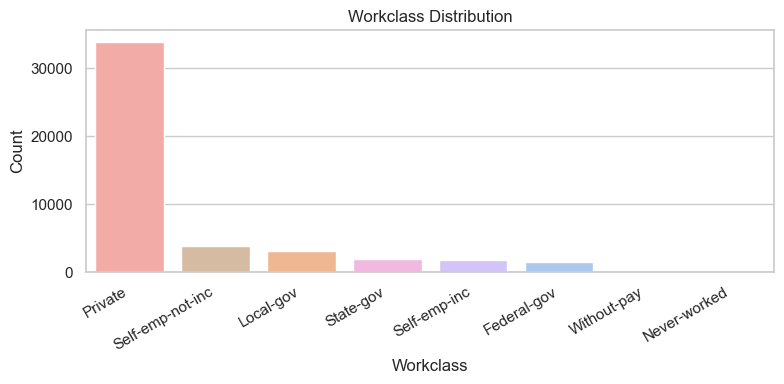

✅ Plot saved to: adult_two_prediction_results\eda_workclass_distribution.png



In [8]:

# Visualization for Workclass (target for Prediction 1-Workclass (Multi-class Classification))
plt.figure(figsize=(8,4))

# Creates a countplot that shows how often each **workclass** category appears in the dataset.
sns.countplot(
    x=df_full["workclass"],
    hue=df_full["workclass"],
    legend=False,
    palette="pastel",
    order=df_full["workclass"].value_counts().index) # Orders bars from most to least frequent

# Add simple and easy-to-understand labels to the plot.
plt.title("Workclass Distribution")
plt.xlabel("Workclass");
plt.ylabel("Count")

# Rotate x-axis labels to prevent overlap and make them easier to read
plt.xticks(rotation=30, ha='right')

#Save the finished plot in the output folder for documentation
save_plot("eda_workclass_distribution.png")


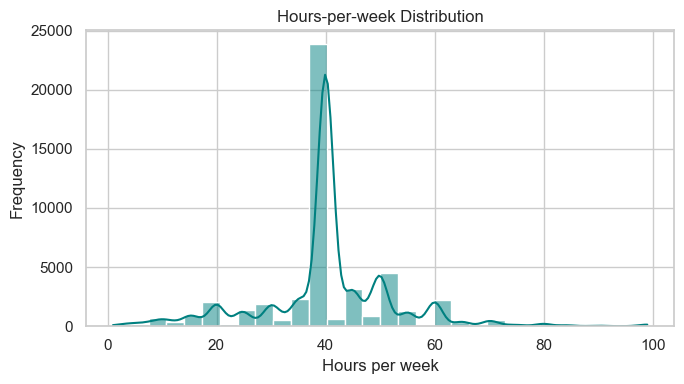

✅ Plot saved to: adult_two_prediction_results\eda_hours_per_week_distribution.png



In [9]:
# Visualization for Hours-per-week (target for Prediction 2- Hours-per-week buckets (Multi-class Classification))
plt.figure(figsize=(7,4))
sns.histplot(
    df_full["hours-per-week"],
    bins=30, kde=True, 
    color="teal"
)
plt.title("Hours-per-week Distribution")
plt.xlabel("Hours per week"); plt.ylabel("Frequency")

#Save the finished plot in the output folder for documentation
save_plot("eda_hours_per_week_distribution.png")

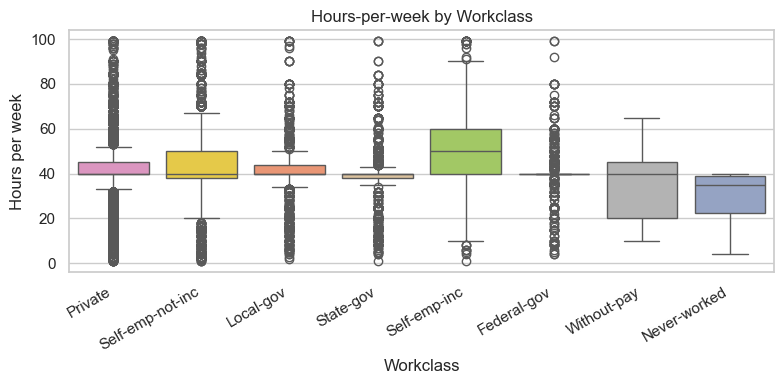

✅ Plot saved to: adult_two_prediction_results\eda_hours_by_workclass_boxplot.png



In [10]:
# Visualization for hours-per-week by workclass
plt.figure(figsize=(8,4))
sns.boxplot(
    x=df_full["workclass"], 
    y=df_full["hours-per-week"], 
    hue=df_full["workclass"], 
    legend=False, 
    palette="Set2",
    order=df_full["workclass"].value_counts().index
)

plt.title("Hours-per-week by Workclass")
plt.xlabel("Workclass"); plt.ylabel("Hours per week")
plt.xticks(rotation=30, ha='right')
save_plot("eda_hours_by_workclass_boxplot.png")

In [11]:

# Preprocessing the Dataset

def build_preprocessor(X, drop_cols=None):
    """
This builds a preprocessing pipeline using Scikit-learn's ColumnTransformer.

Purpose:
- Separates numeric and categorical features automatically.
- Applies suitable transformations to each type (scaling, encoding, imputing).
- Keeps preprocessing consistent for different prediction tasks.
"""
    # Copy input data to keep the original safe
    Xp = X.copy()

    # Drop unwanted columns (e.g., IDs or redundant fields)
    if drop_cols:
        Xp.drop(columns=[c for c in drop_cols if c in Xp.columns], inplace=True)
        
# Identify numeric and categorical features
    num_cols = Xp.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = Xp.select_dtypes(include=["object", "category"]).columns.tolist()
    
# Numeric preprocessing: fill missing values and scale 
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    # Categorical preprocessing: fill missing values and encode 
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    
# Combine both numeric and categorical transformations 
    pre = ColumnTransformer(transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ], remainder="drop"
    )

    # Returns the preprocessor and lists of feature names for later use
    return pre, num_cols, cat_cols, Xp



In [12]:

#  Training & Testing

def train_and_evaluate(X, y, task_name, preprocessor, models):
    # Created a stratified train/test split to keep class proportions consistent
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    print(f"\n--- {task_name.upper()} — Train/Test shapes:", X_train.shape, X_test.shape)

    # Prepared a dictionary to store metrics for each model
    results = []
    
    # Trained and evaluated each model using the same pipeline
    for name, clf in models.items():
        # The pipeline makes sure preprocessing is applied the same way during training and testing
        pipe = Pipeline(steps=[("pre", preprocessor), ("clf", clf)])
        print(f"\nTraining {name} for {task_name} ...")
        pipe.fit(X_train, y_train)
        
       # Generated predictions on the test set
        y_pred = pipe.predict(X_test)
        
       # Computed metrics (macro-averaged to handle multi-class and imbalanced data fairly)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

        results.append({
            "task": task_name,
            "model": name,
            "accuracy": acc,
            "macro_f1": f1_macro,
            "macro_precision": prec_macro,
            "macro_recall": rec_macro
        })

         #  CONFUSION MATRIX VISUALIZATION 
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix — {task_name} — {name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")

        # Saved plot with descriptive name
        fname = f"cm_{task_name}_{name}.png".replace(" ", "_")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight", dpi=300)
        plt.show()
        plt.close()
        print(f" Saved confusion matrix: {fname}")

        # Saved top feature importances for RandomForest 
        if isinstance(clf, RandomForestClassifier):

            # Rebuilt the feature names after encoding, in the same order the model sees them
            ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
            cat_names = list(ohe.get_feature_names_out(
                pipe.named_steps["pre"].transformers_[1][2]
            ))
            num_names = pipe.named_steps["pre"].transformers_[0][2]
            all_names = list(num_names) + cat_names

           # Ranked features by importance and save the top 15 for documentation
            importances = pipe.named_steps["clf"].feature_importances_
            top = np.argsort(importances)[-15:][::-1]
            top_df = pd.DataFrame({
                "feature": [all_names[i] for i in top],
                "importance": importances[top]
            })
            csv_name = f"rf_top_features_{task_name}.csv"
            top_df.to_csv(os.path.join(OUT_DIR, csv_name), index=False)

    # Saved Summary
    summary_df = pd.DataFrame(results)
    csv = f"summary_{task_name}.csv"
    summary_df.to_csv(os.path.join(OUT_DIR, csv), index=False)
    print(f"\nSaved summary to {csv}")
    return summary_df


***Tasks Modeled***

**1. Workclass Prediction (Multi-class classification)**

**2. Hours-per-Week Bucket Prediction (Part-time, Full-time, Overtime)**




--- WORKCLASS — Train/Test shapes: (36834, 12) (9209, 12)

Training LogisticRegression for workclass ...


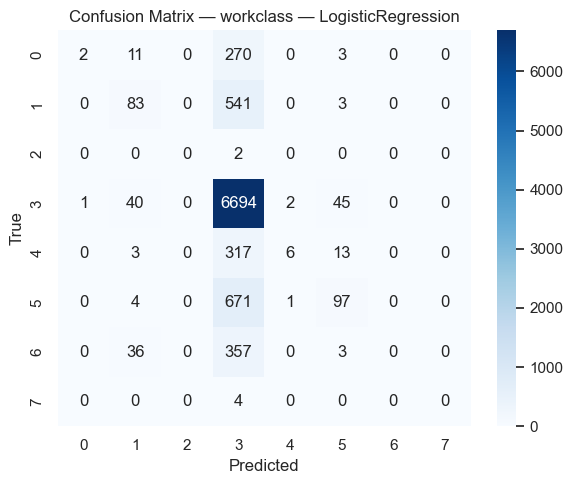

 Saved confusion matrix: cm_workclass_LogisticRegression.png

Training RandomForest for workclass ...


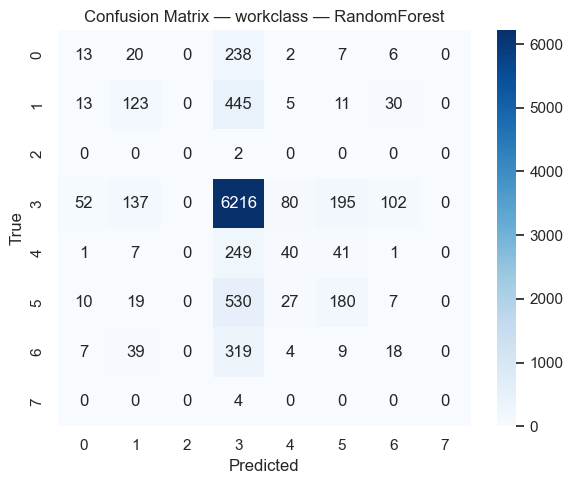

 Saved confusion matrix: cm_workclass_RandomForest.png

Saved summary to summary_workclass.csv


In [13]:

# Prediction 1 — Workclass (Multi-class Classification)

#   Defined the target for this Prediction (workclass) 
y_work = df_full["workclass"].copy()

# Kept only rows where the target value exists to avoid training on missing targets 
mask_work = y_work.notna()
X_work_full = df_full.loc[mask_work].copy()
y_work = y_work.loc[mask_work]

#  To Prepare features, i droped the target column and any irrelevant or duplicate fields 
# 'fnlwgt' is a sample weight and not useful for prediction.
# 'education' is removed because 'education-num' gives a cleaner numeric version.
pre_work, num_cols_work, cat_cols_work, X_work = build_preprocessor(
    X_work_full.drop(columns=["workclass"]), drop_cols=["fnlwgt", "education"]
)

# Chose candidate models: one linear and one non-linear 
models_work = {
    "LogisticRegression": LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    # Logistic Regression → strong linear baseline for multi-class problems (One-vs-Rest)
    
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    # Random Forest → captures non-linear relationships and works well with tabular data
}

# Trained and evaluated both models using the same pipeline and performance metrics 
summary_work = train_and_evaluate(
    X_work, y_work, task_name="workclass", preprocessor=pre_work, models=models_work
)



Hours bucket distribution:
 hours-per-week
full-time    26639
over-time    14352
part-time     7851
Name: count, dtype: int64

--- HOURS_BUCKET — Train/Test shapes: (39073, 12) (9769, 12)

Training LogisticRegression for hours_bucket ...


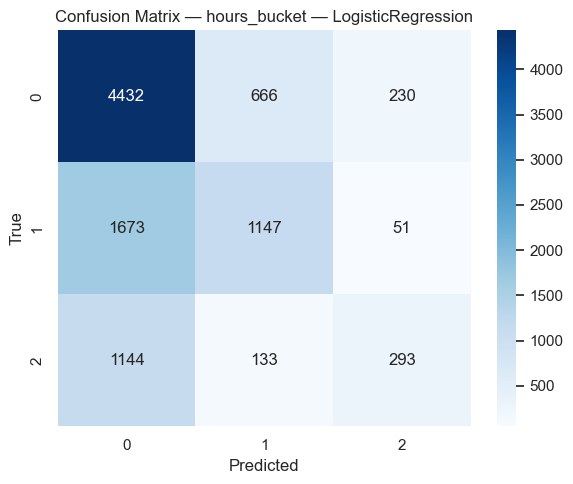

 Saved confusion matrix: cm_hours_bucket_LogisticRegression.png

Training RandomForest for hours_bucket ...


In [ ]:

# Prediction 2 — Hours-per-week buckets (Multi-class Classification)


# Created a categorical target from the numeric 'hours-per-week' feature 
def categorize_hours(h):
    if h <= 30:   return "part-time"   # ≤30
    elif h <= 40: return "full-time"   # 31–40
    else:         return "over-time"   # >40
        
# This Converts continuous working hours into practical categories 
# (part-time, full-time, over-time) for a multi-class classification task.
y_hours = df_full["hours-per-week"].apply(categorize_hours)

# Checked class balance quickly to spot any imbalance issues 
print("\nHours bucket distribution:\n", y_hours.value_counts())

# Removed 'hours-per-week' to prevent target leakage (since it's used to create y_hours).
# Drop 'fnlwgt' (sampling weight) and 'education' (already represented as 'education-num').
pre_hours, num_cols_hours, cat_cols_hours, X_hours = build_preprocessor(
    df_full.drop(columns=["hours-per-week"]), drop_cols=["fnlwgt", "education"]
)

#  Chose candidate models: one linear and one non-linear 
models_hours = {
    "LogisticRegression": LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    # Logistic Regression → easy to interpret linear baseline (One-vs-Rest for multi-class)
    
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    # Random Forest → handles non-linear patterns and works well on tabular data
}

# Trained and evaluated both models using the same pipeline and macro-averaged metrics 
summary_hours = train_and_evaluate(
    X_hours, y_hours, task_name="hours_bucket", preprocessor=pre_hours, models=models_hours
)


In [ ]:

# Combine and Export Overall Results for Both Prediction Tasks

# Merge the two result summaries (Workclass + Hours Bucket) into one DataFrame 
# Combines performance metrics from both classification tasks for direct comparison.
overall_only_new = pd.concat([summary_work, summary_hours], ignore_index=True)

#  Saved the combined summary to the output directory 
overall_only_new.to_csv(
    os.path.join(OUT_DIR, "overall_summary_predicitons_1_&_2.csv"), index=False)
# Exports the unified results as a CSV file for easy inclusion in reports or further analysis.

# Display results in notebook for quick review 
print("\n=== Overall Summary (Prediction 1 & 2) ===\n", overall_only_new)
print("\nAll outputs saved in:", OUT_DIR)


**CONCLUSION**

This Python workflow demonstrates how to design a reliable, explainable, and
reproducible machine learning pipeline for real-world demographic prediction tasks. 
It combines EDA, preprocessing, modeling, and evaluation into a single structured process, enabling clear insights into 
which features most strongly influence employment patterns.